# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz
**Fecha:** 17 de Marzo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie.

## 1. Importe de librerias

Se cargan las librerías necesarias para manipulación de datos, procesamiento de imágenes y modelado con redes neuronales. Algunas destacadas:

* Pandas y NumPy: Para manejo de datos.
* Matplotlib y Seaborn: Para visualización.
* OpenCV (cv2) y PIL (Image): Para procesamiento de imágenes.
* TensorFlow y Keras: Para construir y entrenar modelos de deep learning.
* GridSearch: Para búsqueda de hiperparámetros

In [4]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers
from keras import optimizers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import wrappers
from scikeras.wrappers import KerasClassifier, KerasRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [5]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-03-17 16:49:01.563563


## 2. Importe de Datos
* Se importa un archivo CSV (Data_Final.csv) con el listado de imágenes y etiquetas.
* Se eliminan registros de la clase "Orange".
* Se divide el dataset en 80% entrenamiento - 20% prueba, asegurando balance entre clases con stratify.

In [9]:
train=pd.read_csv('Data_Final.csv', sep=";")
train.head()

,Carpeta,Nombre del archivo,Planta,Condición,Saludable
0,Strawberry___healthy,8f558908-aa1b-4a86-855a-5094c2392e5a___RS_HL 1...,Strawberry,healthy,SI
1,Strawberry___healthy,b8e9ed27-8e37-4214-9206-f8c0ef21cf4d___RS_HL 4...,Strawberry,healthy,SI
2,Strawberry___healthy,abdd34a0-ab02-41e0-95a3-a014ab863ec2___RS_HL 1...,Strawberry,healthy,SI
3,Strawberry___healthy,d1aee44a-b6bb-45b9-b7b6-5d553add8fd1___RS_HL 2...,Strawberry,healthy,SI
4,Strawberry___healthy,3d28c3ea-8419-4e09-addd-211e3828e39f___RS_HL 1...,Strawberry,healthy,SI


In [11]:
#Quitar las naranjas 
train = train[train["Planta"] != "Orange"]

## 3. Análisis de Datos y Creación de conjuntos de train & test

* Se analiza la distribución de imágenes por categoría mediante gráficos de conteo.
Se visualizan imágenes de plantas saludables y enfermas usando OpenCV.

Se obtiene el tamaño de las imágenes para estandarizar el preprocesamiento.

### 3.1. Conteo de imágenes por categoría Plantas (Especies)

In [15]:
train.Planta.value_counts()

Planta
Yuca            21397
Tomato          18160
Grape            4062
Corn_(maize)     3852
Apple            3174
Pepper_bell      2475
Peach            2297
Potato           2152
Strawberry       1565
Name: count, dtype: int64

### 3.2. Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [18]:
train, test= train_test_split( train, test_size=0.2, random_state=42,shuffle=True, stratify=train['Planta'])
train.shape, test.shape

((47307, 5), (11827, 5))

### 3.3. Conteo de imágenes por en el conjunto train por categoría

In [21]:
train.Planta.value_counts()

Planta
Yuca            17117
Tomato          14528
Grape            3249
Corn_(maize)     3082
Apple            2539
Pepper_bell      1980
Peach            1838
Potato           1722
Strawberry       1252
Name: count, dtype: int64

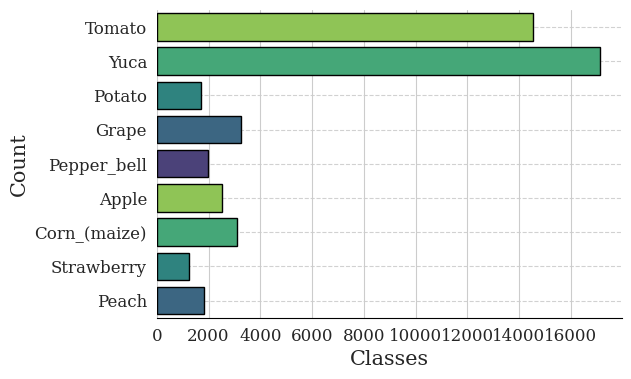

In [23]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(train.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.4. Conteo de imágenes por en el conjunto test por categoría

In [26]:
test.Planta.value_counts()

Planta
Yuca            4280
Tomato          3632
Grape            813
Corn_(maize)     770
Apple            635
Pepper_bell      495
Peach            459
Potato           430
Strawberry       313
Name: count, dtype: int64

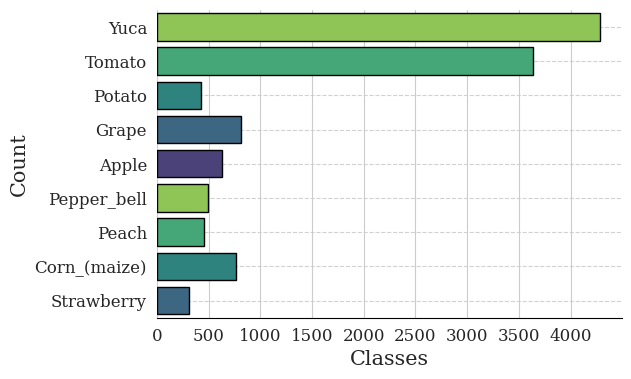

In [28]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(test.Planta, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.5. Muestra de Imagenes

In [31]:
# Cambiar el nombre de la columna
test = test.rename(columns={'Nombre del archivo': 'image_id'})
train = train.rename(columns={'Nombre del archivo': 'image_id'})

In [33]:
train.head()

,Carpeta,image_id,Planta,Condición,Saludable
38289,Tomato___Septoria_leaf_spot,53f8a06e-20f1-4433-b558-01f7e5d14dba___Matt.S_...,Tomato,Septoria_leaf_spot,NO
60108,Casava,4034332345.jpg,Yuca,Cassava Bacterial Blight (CBB),NO
33217,Tomato___Spider_mites Two-spotted_spider_mite,3aad576c-3189-4b78-a5df-c9bac0078612___Com.G_S...,Tomato,Spider_mites Two-spotted_spider_mite,NO
6146,Potato___Late_blight,9570095c-02e9-497b-bec1-4e526f3462e5___RS_LB 2...,Potato,Late_blight,NO
63587,Casava,795796251.jpg,Yuca,Cassava Bacterial Blight (CBB),NO


#### Plantas Healthy

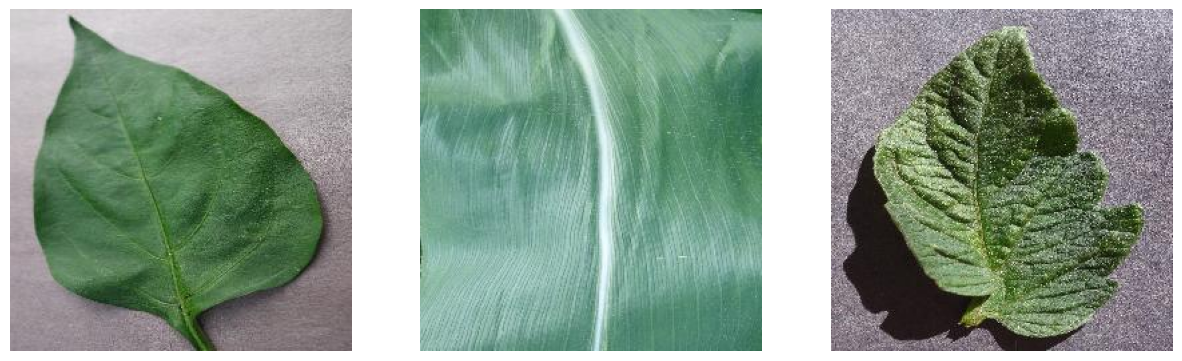

In [36]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "SI"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con alguna enfermedad

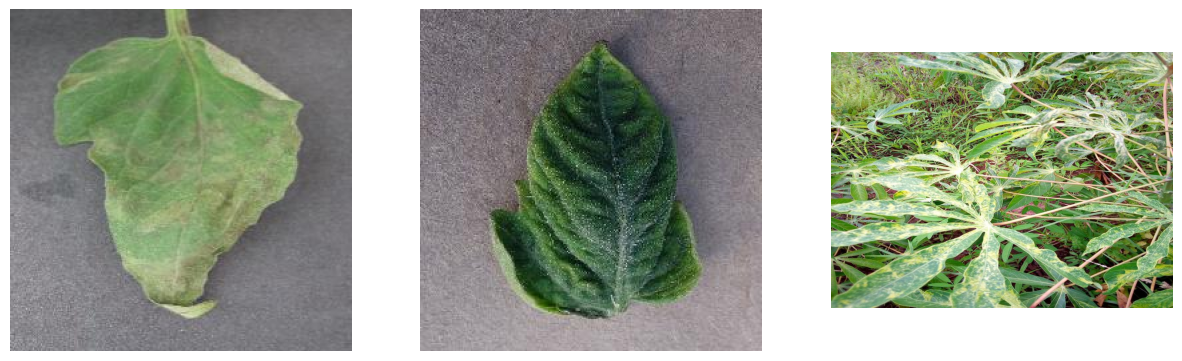

In [39]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.Saludable == "NO"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "Datos Finales"

for ind, (image_id, Planta) in enumerate(zip(sample.image_id, sample.Planta)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

Obtener el tamaño de las imágenes

In [42]:
image_path = os.path.join(image_folder, image_id)

# Definir la carpeta con las imágenes
image_folder = "Datos Finales"

# Función para obtener el tamaño de una imagen
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            return img.size  # Devuelve (ancho, alto)
    except Exception as e:
        print(f"Error con la imagen {image_path}: {e}")
        return None, None

In [44]:
# Obtener el tamaño de cada imagen y agregarlo al DataFrame
widths = []
heights = []

for img_name in train["image_id"]:  # Asegúrate de que la columna se llama "image_id"
    img_path = os.path.join(image_folder, img_name)
    width, height = get_image_size(img_path)
    widths.append(width)
    heights.append(height)

train["width"] = widths
train["height"] = heights

# Mostrar las primeras filas con los nuevos datos
print(train.head())

Error con la imagen Datos Finales/db19f539-05e8-4cd8-a9bc-57fb97ce0f41___RS_NLB  4443 copy.jpg: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/db19f539-05e8-4cd8-a9bc-57fb97ce0f41___RS_NLB\xa0 4443 copy.jpg'
Error con la imagen Datos Finales/90dd4436-0614-4f6b-ad3b-b8db56ce4de8___RS_NLB  4673.JPG: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/90dd4436-0614-4f6b-ad3b-b8db56ce4de8___RS_NLB\xa0 4673.JPG'
Error con la imagen Datos Finales/archivos_plantvillage.csv: cannot identify image file '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/archivos_plantvillage.csv'
Error con la imagen Datos Finales/ea9ba5b2-e8e7-48c8-ac16-d594a9e5cc51___RS_NLB  4443 copy 2.jpg: [Errno 2] No such file or directory: '/Users/mfia/Documents/MFIA - PUJ - Maestría/Proyecto de Grado/0. Data/Datos Finales/ea9ba5b2-e8e7-48c8-a

## 4. Preparación del Modelo

* Se implementará data augmentation para mejorar la generalización.
* Se evaluará el modelo con métricas como precisión y recall.

In [46]:
# Hiperparámetros principales
BATCH_SIZE = 8
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 10
TARGET_SIZE = 150

In [49]:
train.Planta = train.Planta.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "Datos Finales",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 37829 validated image filenames belonging to 9 classes.
Found 9457 validated image filenames belonging to 9 classes.


Imágen Aleatoria antes de Augmentation

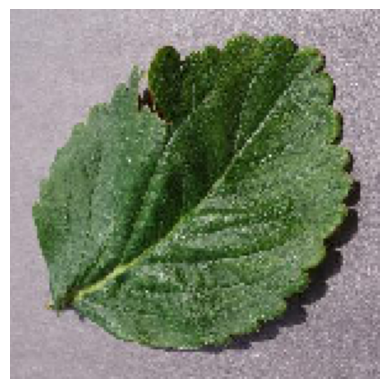

In [52]:
img_path = os.path.join("Datos Finales", train.image_id[20])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

In [54]:
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "Datos Finales",
                         x_col = "image_id",
                         y_col = "Planta",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

aug_images = [generator[0][0][0]/255 for i in range(10)]
fig, axes = plt.subplots(2, 5, figsize = (TARGET_SIZE, TARGET_SIZE))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

Found 1 validated image filenames belonging to 1 classes.


## 5. Construcción del Modelo

### 5.1. Función Clasificador

Se crea el modelo como una función para poder buscar los mejores hiperparámetros

**Arquitectura del Modelo CNN**
El modelo es una red neuronal convolucional (**CNN**) diseñada para clasificar imágenes de plantas en distintas categorías. Su arquitectura incluye:

**1. Capas Convolucionales y de MaxPooling**
Cada capa convolucional extrae características de las imágenes, mientras que **MaxPooling** reduce la dimensionalidad, mejorando la eficiencia del modelo.

- **Capa 1:**  
  - `Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3))`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 2:**  
  - `Conv2D(64, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 3:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

- **Capa 4:**  
  - `Conv2D(128, (3,3), activation='relu')`  
  - `BatchNormalization()`
  - `MaxPooling2D(2,2)`

**2. Capa de Aplanamiento**
Después de las capas convolucionales, se usa `Flatten()` para convertir la salida en un vector de una dimensión.

**3. Capas Densas y Regularización**
- Una capa densa con **512 neuronas** y función de activación ReLU.
- Se usa **Dropout (0.5)** para reducir el sobreajuste.
  
**4. Capa de Salida**
- `Dense(9, activation='softmax')`  
- La activación **softmax** se usa porque se trata de un problema de clasificación multiclase (9 categorías).

In [65]:
# Función para crear el modelo con hiperparámetros ajustables
def create_model(model, optimizer='adam', dropout_rate=0.5, filters=32):
    model = models.Sequential()

    # Capas convolucionales y de MaxPooling
    model.add(layers.Conv2D(filters, (3, 3), activation='relu', input_shape=(150, 150, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(filters * 2, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(filters * 4, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(filters * 4, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    # Aplanamiento y capas densas
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(9, activation='softmax'))
    

In [67]:
model.summary

NameError: name 'model' is not defined

### 5.2. Compilación del modelo

In [61]:
# Compilación
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
return model

NameError: name 'model' is not defined

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,458,633 (13.19 MB)

 Trainable params: 3,457,929 (13.19 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Crear el modelo para GridSearch
model = KerasClassifier(build_fn=create_model, verbose=0)

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'dropout_rate': [0.3, 0.5, 0.7],
    'filters': [32, 64],
    'batch_size': [16, 32],
    'epochs': [10, 20]
}

## 6. Ejecución del modelo

* Se entrenará el modelo utilizando Adam como optimizador y EarlyStopping para prevenir sobreajuste.
* Se evaluará el desempeño sobre el conjunto de prueba.

In [42]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/10


### 6.1. Resultados del Modelo

In [ ]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

In [ ]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")